In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv(r"C:\Users\rudra\Downloads\diabetes.csv")
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [3]:
data.shape

(768, 9)

In [4]:
data.isnull().sum().sum()
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [5]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]

In [6]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,PowerTransformer
import pickle

In [7]:
x.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31


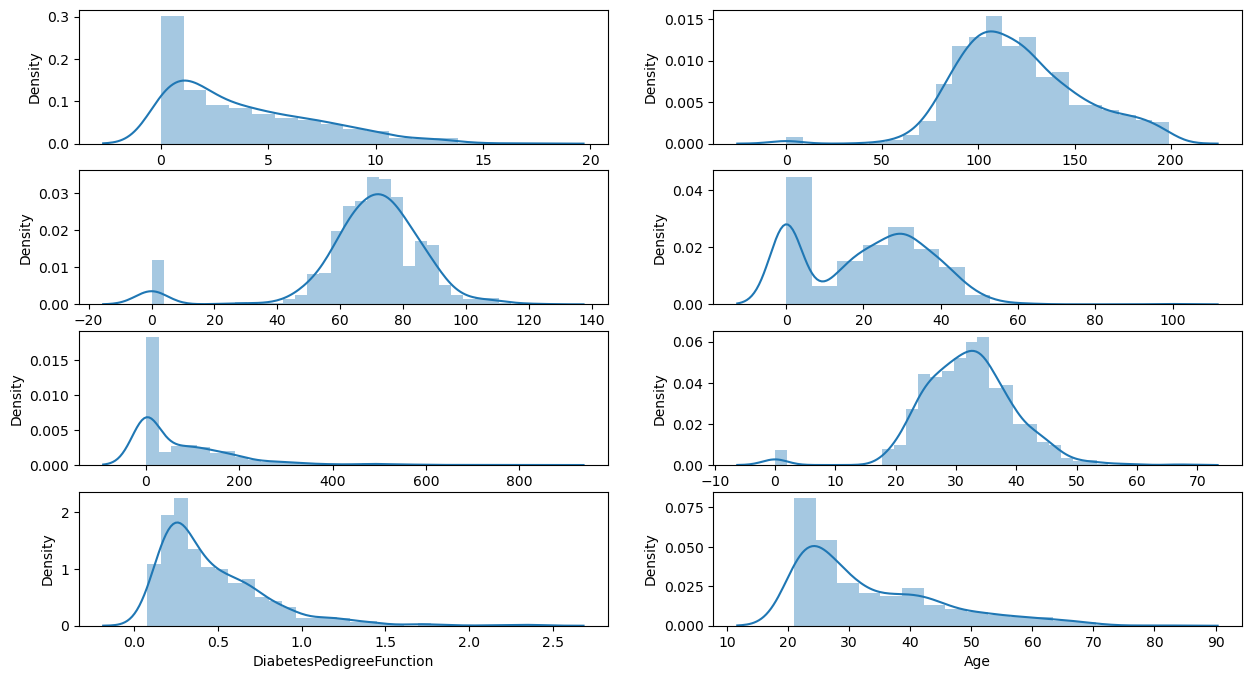

In [8]:
plt.figure(figsize=(15,8))
for i,var in enumerate(x.columns):
    plt.subplot(4,2,i+1)
    ax=sns.distplot(x[var])

In [9]:
ct=ColumnTransformer([
    ('st',StandardScaler(),x.columns),
    ('ft',PowerTransformer(),x.columns)
])
ct

ColumnTransformer(transformers=[('st', StandardScaler(),
                                 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                ('ft', PowerTransformer(),
                                 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
pipe_logistic=Pipeline([
    ('ct',ct),
    ('model',LogisticRegression(class_weight="balanced"))
])
pipe_logistic

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('st', StandardScaler(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('ft', PowerTransformer(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [12]:
pipe_logistic.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('st', StandardScaler(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('ft', PowerTransformer(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [13]:
print(pipe_logistic.score(x_train,y_train)*100)
print(pipe_logistic.score(x_test,y_test)*100)

76.70043415340086
70.12987012987013


In [14]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,pipe_logistic.predict(x_test))
cm

array([[33, 17],
       [ 6, 21]])

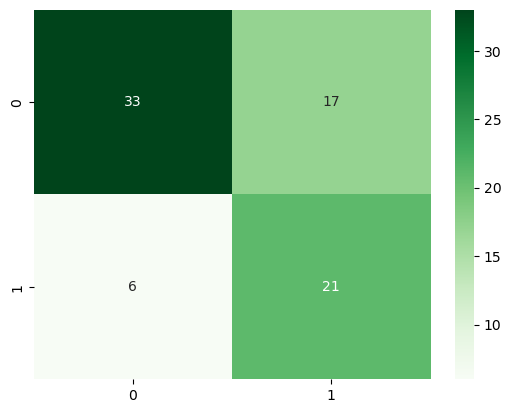

In [15]:
sns.heatmap(data=cm,annot=True,cmap='Greens')
plt.show()

In [16]:
print(precision_score(y_test,pipe_logistic.predict(x_test))*100)
print(recall_score(y_test,pipe_logistic.predict(x_test))*100)
print(f1_score(y_test,pipe_logistic.predict(x_test))*100)

55.26315789473685
77.77777777777779
64.61538461538461


## SVM

In [17]:
from sklearn.svm import SVC
pipe_svm=Pipeline([
    ('ct',ct),
    ('model',SVC(class_weight='balanced',kernel='rbf'))
])
pipe_svm.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('st', StandardScaler(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('ft', PowerTransformer(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])),
                ('model', SVC(class_weight='balanced'))])

In [18]:
print(pipe_svm.score(x_train,y_train)*100)
print(pipe_svm.score(x_test,y_test)*100)

81.33140376266282
66.23376623376623


In [19]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,pipe_svm.predict(x_test))
cm

array([[31, 19],
       [ 7, 20]])

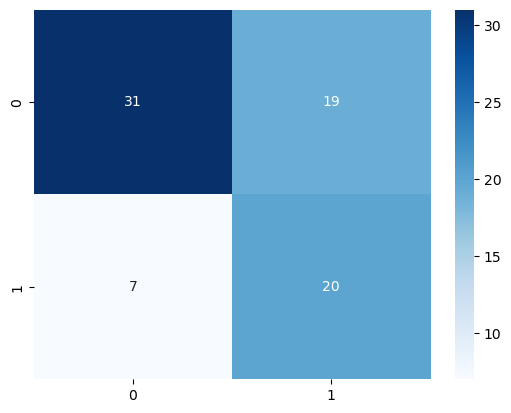

In [20]:
sns.heatmap(data=cm,annot=True,cmap='Blues')
plt.show()

In [21]:
print(precision_score(y_test,pipe_svm.predict(x_test))*100)
print(recall_score(y_test,pipe_svm.predict(x_test))*100)
print(f1_score(y_test,pipe_svm.predict(x_test))*100)

51.28205128205128
74.07407407407408
60.60606060606061


## Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB
pipe_nb=Pipeline([
    ('ct',ct),
    ('gnb',GaussianNB())
])
pipe_nb.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('st', StandardScaler(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('ft', PowerTransformer(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])),
                ('gnb', GaussianNB())])

In [23]:
print(pipe_nb.score(x_train,y_train)*100)
print(pipe_nb.score(x_test,y_test)*100)

76.12156295224312
64.93506493506493


In [24]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,pipe_nb.predict(x_test))
cm

array([[31, 19],
       [ 8, 19]])

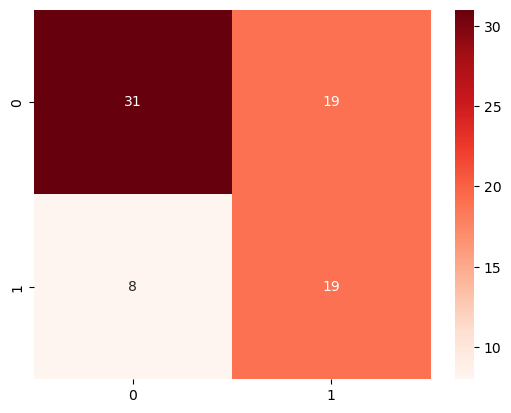

In [25]:
sns.heatmap(data=cm,annot=True,cmap='Reds')
plt.show()

In [26]:
print(precision_score(y_test,pipe_nb.predict(x_test))*100)
print(recall_score(y_test,pipe_nb.predict(x_test))*100)
print(f1_score(y_test,pipe_nb.predict(x_test))*100)

50.0
70.37037037037037
58.46153846153847


In [27]:
import pickle
pickle.dump(pipe_logistic,open('pipe_logistic.pkl',"wb"))
pipe_logistic=pickle.load(open('pipe_logistic.pkl',"rb"))

In [28]:
pipe_logistic

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('st', StandardScaler(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('ft', PowerTransformer(),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object'))])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [29]:
pipe_logistic.predict(pd.DataFrame([[6,148,72,35,0,33.6,0.627,50]],columns=x.columns))

array([1])

#